Importations

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from re import sub
from sklearn.cluster import KMeans

STEP 1: Plot congestion function

In [ ]:



def plot_congestion_snapshot(time_min_vec):
    """
    Plot congestion snapshots of the road network at specified times.

    Parameters
    ----------
    time_min_vec : list or array-like
        Requested snapshot times in minutes.

    Example
    -------
    plot_congestion_snapshot([60, 90, 120])

    Required files
    --------------
    links.csv
    nodes.csv
    occupancy.csv

    The CSV files should be located in the same folder as this
    Python file.

    Occupancy = 0%   -> white
    Occupancy = 100% -> black
    """

    # ----------------------------------------------------------
    # 1. Locate and read data
    # ----------------------------------------------------------



    # links.csv and nodes.csv contain numerical data without
    # a header row
    links = pd.read_csv(
        data_dir / "links.csv",
        header=None
    ).to_numpy()

    nodes = pd.read_csv(
        data_dir / "nodes.csv",
        header=None
    ).to_numpy()

    # occupancy.csv:
    # first row    = link IDs
    # first column = time [sec]
    occupancy_raw = pd.read_csv(
        data_dir / "occupancy.csv",
        header=None
    ).to_numpy()

    # ----------------------------------------------------------
    # 2. Network information
    # ----------------------------------------------------------

    # links.csv columns:
    # 0 = Link ID
    # 1 = Length
    # 2 = Number of lanes
    # 3 = Starting node ID
    # 4 = Ending node ID
    # 5 = Region

    link_id = links[:, 0].astype(int)
    start_node = links[:, 3].astype(int)
    end_node = links[:, 4].astype(int)

    # nodes.csv columns:
    # 0 = Node ID
    # 1 = x-coordinate
    # 2 = y-coordinate

    node_id = nodes[:, 0].astype(int)
    node_x = nodes[:, 1].astype(float)
    node_y = nodes[:, 2].astype(float)

    # ----------------------------------------------------------
    # 3. Occupancy data
    # ----------------------------------------------------------

    occupancy_link_id = occupancy_raw[0, 1:].astype(int)

    time_sec = occupancy_raw[1:, 0].astype(float)

    occupancy = occupancy_raw[1:, 1:].astype(float)

    # ----------------------------------------------------------
    # 4. Match occupancy columns with links.csv
    # ----------------------------------------------------------

    occupancy_id_to_col = {
        link: j
        for j, link in enumerate(occupancy_link_id)
    }

    occupancy_columns = []

    for link in link_id:

        if link not in occupancy_id_to_col:
            raise ValueError(
                f"Link {link} from links.csv was not found "
                f"in occupancy.csv."
            )

        occupancy_columns.append(
            occupancy_id_to_col[link]
        )

    # Reorder occupancy columns so they follow links.csv
    occupancy = occupancy[:, occupancy_columns]

    # ----------------------------------------------------------
    # 5. Map node IDs to coordinates
    # ----------------------------------------------------------

    node_coordinates = {
        node_id[i]: (node_x[i], node_y[i])
        for i in range(len(node_id))
    }

    segments = []

    for i in range(len(link_id)):

        s = start_node[i]
        e = end_node[i]

        if s not in node_coordinates:
            raise ValueError(
                f"Start node {s} was not found in nodes.csv."
            )

        if e not in node_coordinates:
            raise ValueError(
                f"End node {e} was not found in nodes.csv."
            )

        x1, y1 = node_coordinates[s]
        x2, y2 = node_coordinates[e]

        segments.append([
            [x1, y1],
            [x2, y2]
        ])

    # ----------------------------------------------------------
    # 6. Process requested times
    # ----------------------------------------------------------

    time_min_vec = np.atleast_1d(
        np.asarray(time_min_vec, dtype=float)
    )

    n_plots = len(time_min_vec)

    if n_plots == 0:
        raise ValueError(
            "time_min_vec must contain at least one time."
        )

    # ----------------------------------------------------------
    # 7. Determine subplot layout automatically
    # ----------------------------------------------------------

    if n_plots <= 3:

        n_rows = 1
        n_cols = n_plots

    else:

        n_rows = int(np.floor(np.sqrt(n_plots)))
        n_cols = int(np.ceil(n_plots / n_rows))

    # ----------------------------------------------------------
    # 8. Create figure
    # ----------------------------------------------------------

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 5 * n_rows),
        squeeze=False
    )

    axes = axes.flatten()

    # Common occupancy-to-color mapping
    norm = Normalize(
        vmin=0,
        vmax=100
    )

    # Greys:
    # 0   -> white
    # 100 -> black
    cmap = plt.get_cmap("Greys")

    # ----------------------------------------------------------
    # 9. Plot requested snapshots
    # ----------------------------------------------------------

    for j, time_min in enumerate(time_min_vec):

        ax = axes[j]

        target_time_sec = time_min * 60

        # Check whether requested time is within simulation
        if (
            target_time_sec < np.min(time_sec)
            or
            target_time_sec > np.max(time_sec)
        ):

            ax.text(
                0.5,
                0.5,
                f"t = {time_min:g} min\n"
                f"is outside the simulation period",
                ha="center",
                va="center",
                transform=ax.transAxes
            )

            ax.axis("off")
            continue

        # Find nearest available measurement
        row = np.argmin(
            np.abs(time_sec - target_time_sec)
        )

        actual_time_sec = time_sec[row]
        actual_time_min = actual_time_sec / 60

        occupancy_vec = occupancy[row, :]

        # Restrict occupancy to [0, 100]
        occupancy_vec = np.clip(
            occupancy_vec,
            0,
            100
        )

        # ------------------------------------------------------
        # Plot road links
        # ------------------------------------------------------

        collection = LineCollection(
            segments,
            cmap=cmap,
            norm=norm,
            linewidths=1.5
        )

        # Occupancy directly controls link color
        collection.set_array(
            occupancy_vec
        )

        ax.add_collection(
            collection
        )

        ax.autoscale()
        ax.set_aspect("equal")
        ax.axis("off")

        # If requested time exactly matches measurement time
        if np.isclose(
            actual_time_sec,
            target_time_sec
        ):

            title_text = (
                f"t = {time_min:g} min"
            )

        # Otherwise show actual measurement time used
        else:

            title_text = (
                f"t = {actual_time_min:g} min "
                f"(nearest to {time_min:g} min)"
            )

        ax.set_title(
            title_text,
            fontweight="bold"
        )

    # ----------------------------------------------------------
    # 10. Hide unused subplot positions
    # ----------------------------------------------------------

    for j in range(n_plots, len(axes)):
        axes[j].axis("off")

    # ----------------------------------------------------------
    # 11. Shared colorbar
    # ----------------------------------------------------------

    sm = ScalarMappable(
        norm=norm,
        cmap=cmap
    )

    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes.tolist(),
        fraction=0.025,
        pad=0.02
    )

    cbar.set_label(
        "Occupancy (%)"
    )

    cbar.set_ticks(
        [0, 20, 40, 60, 80, 100]
    )

    # ----------------------------------------------------------
    # 12. Figure title
    # ----------------------------------------------------------

    fig.suptitle(
        "Network Congestion",
        fontsize=14,
        fontweight="bold"
    )

    plt.show()








Use of function

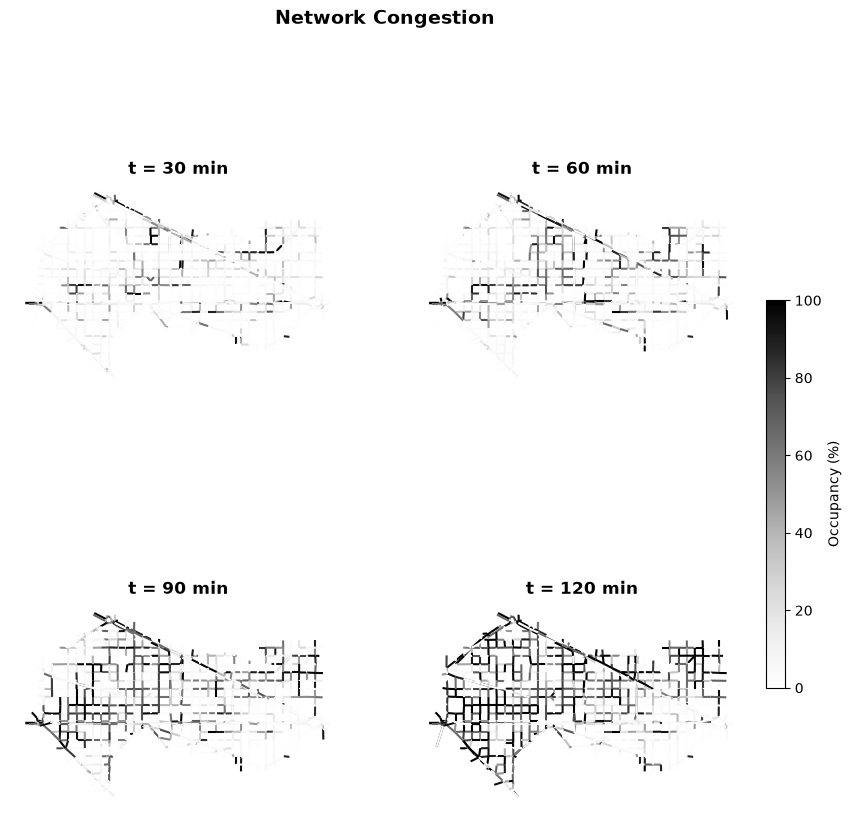

In [57]:
if __name__ == "__main__":
    plot_congestion_snapshot(
        [30, 60, 90, 120]
    )

STEP 2

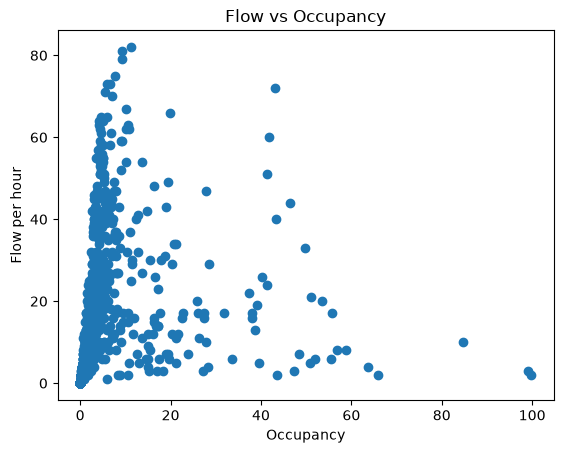

          0           1  2      3      4  5  average_flow  average_occupancy
0       512  109.223913  3  21109  19069  4         969.0           6.692405
1       513  129.668254  3  19067  21109  4         725.5          42.149274
2       514  133.572478  2  19065  21042  4         650.0          65.926014
3       516   47.649608  2     11  19201  3         673.5          49.080196
4       593   96.553539  3  18703     84  4        2688.0          10.454083
...     ...         ... ..    ...    ... ..           ...                ...
1565  69622   13.724368  1  69623  19090  1         124.0          44.454957
1566  70330   15.658167  2  20842  20876  4         737.5          35.260320
1567  72127   12.171527  2  46751  46453  4         259.5           9.992838
1568  73054    2.283717  2  20620  20620  4         112.5          20.289656
1569  73546   80.753891  3  73547  41877  1         615.0          52.606257

[1570 rows x 8 columns]


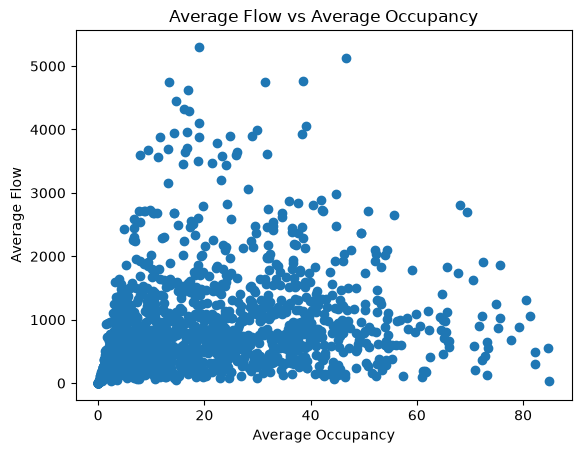

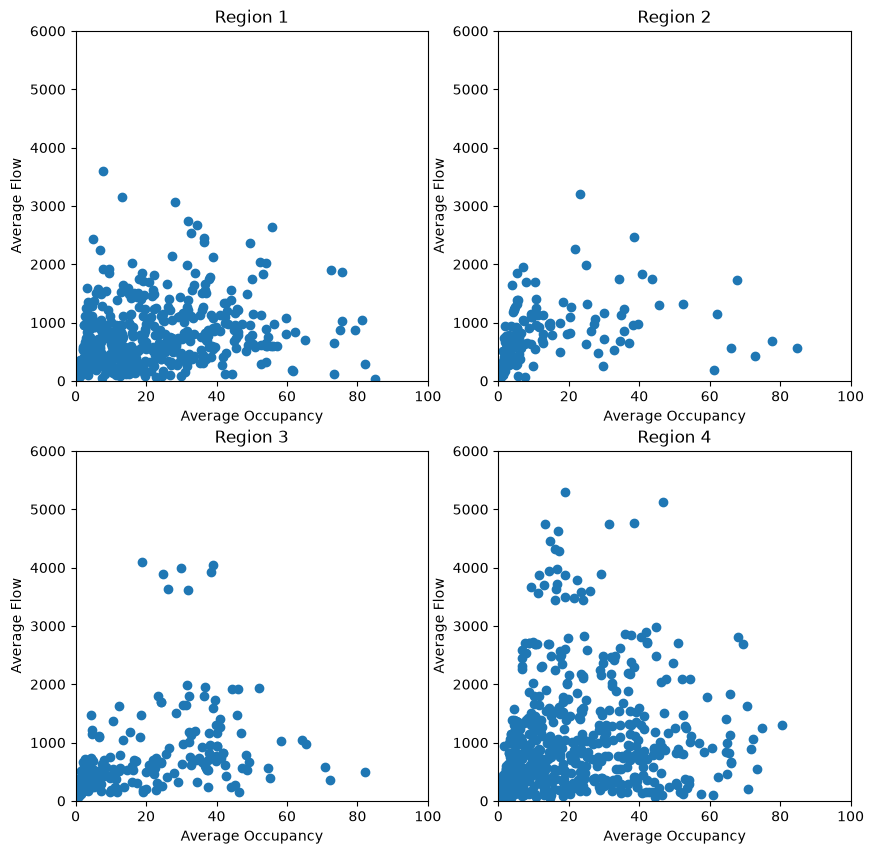

In [58]:
### Step 2
flow = pd.read_csv(
        data_dir / "flow.csv",
        header=None
    ).to_numpy()
occupancy = pd.read_csv(
        data_dir / "occupancy.csv",
        header=None
    ).to_numpy()
flowperhour = flow.copy()
flowperhour[1:,1:] = flow[1:,1:]*3600/90
plt.scatter(occupancy[8][1:],flow[8][1:])
plt.title("Flow vs Occupancy")
plt.xlabel("Occupancy")
plt.ylabel("Flow per hour")
plt.show()

average_flow = np.mean(flowperhour[1:,1:], axis=0)
average_occupancy = np.mean(occupancy[1:,1:], axis=0)
links2 = pd.read_csv(
        data_dir / "links.csv",
        header=None
    )
links2['average_flow'] = average_flow
links2['average_occupancy'] = average_occupancy
print(links2)
plt.scatter(links2['average_occupancy'],links2['average_flow'])
plt.title("Average Flow vs Average Occupancy")
plt.xlabel("Average Occupancy")
plt.ylabel("Average Flow")
plt.show()

fig, axes = plt.subplots(
        2,
        2,
        figsize=(10,10),
        squeeze=False
    )
plt.title("Average Flow vs Average Occupancy by Region")
for i in range(1, 5):
    ax = axes[(i-1)//2, (i-1)%2]
    ax.scatter(links2['average_occupancy'][links2[5]==i],links2['average_flow'][links2[5]==i])
    ax.set_title("Region "+str(i))
    ax.set_xlabel("Average Occupancy")
    ax.set_ylabel("Average Flow")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 6000)
plt.show()

STEP 3

[[0.00000000e+00 1.36650429e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 8.21276714e+00]
 [0.00000000e+00 4.09128143e+00 1.97048000e+00 ... 2.80757571e+00
  2.23884286e-01 1.20667543e+01]
 [6.29112429e+00 8.76154857e+00 5.07900286e+00 ... 0.00000000e+00
  0.00000000e+00 8.95854571e+00]
 ...
 [3.78702571e+00 1.87155171e+01 2.19701609e+02 ... 9.23445714e-01
  9.76190471e+01 2.85714286e+02]
 [4.79285857e+00 1.80590369e+02 1.75705441e+02 ... 2.66723857e+00
  0.00000000e+00 2.85714286e+02]
 [1.11048829e+01 2.85714286e+02 2.84301649e+02 ... 3.66950286e+00
  9.65116271e+01 2.85714286e+02]]
Link density table saved to: c:\Users\grego\Documents\Master\Traffic\Lab1_materials\traffic-operations-lab01\link_density_estimates.csv
Regional mean speed range: 1.98 to 59.43 km/h


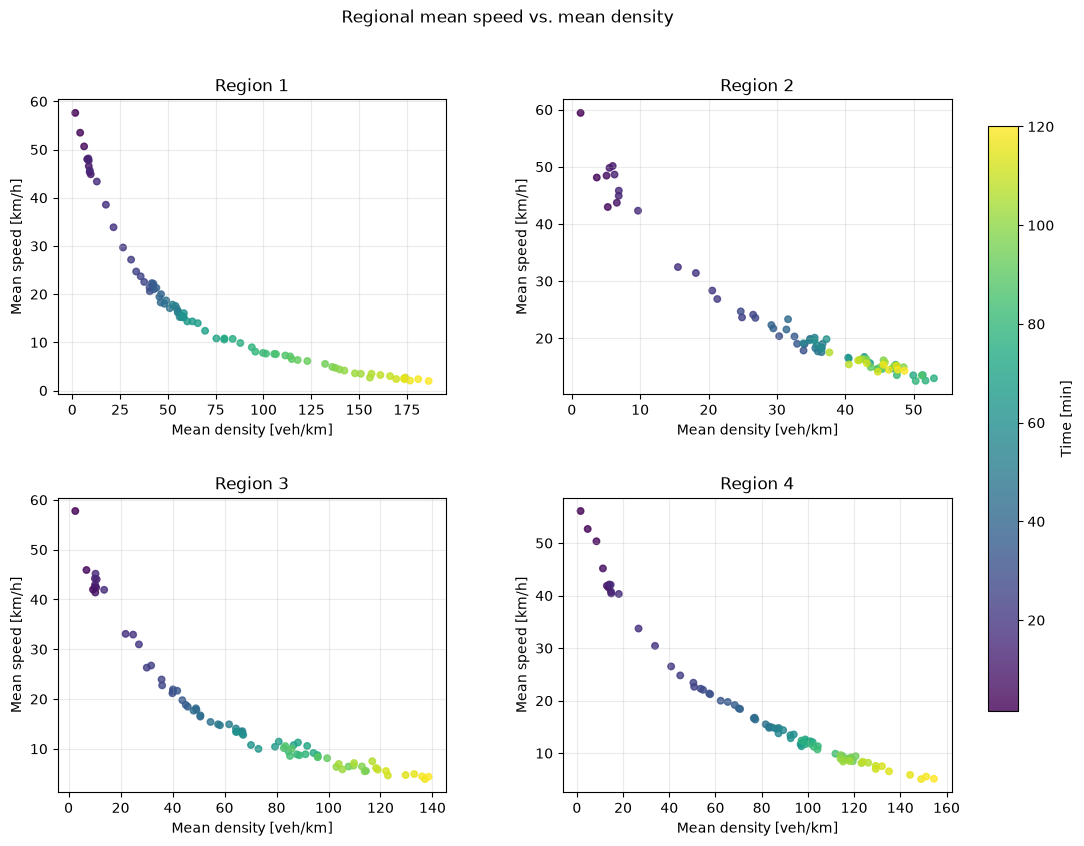

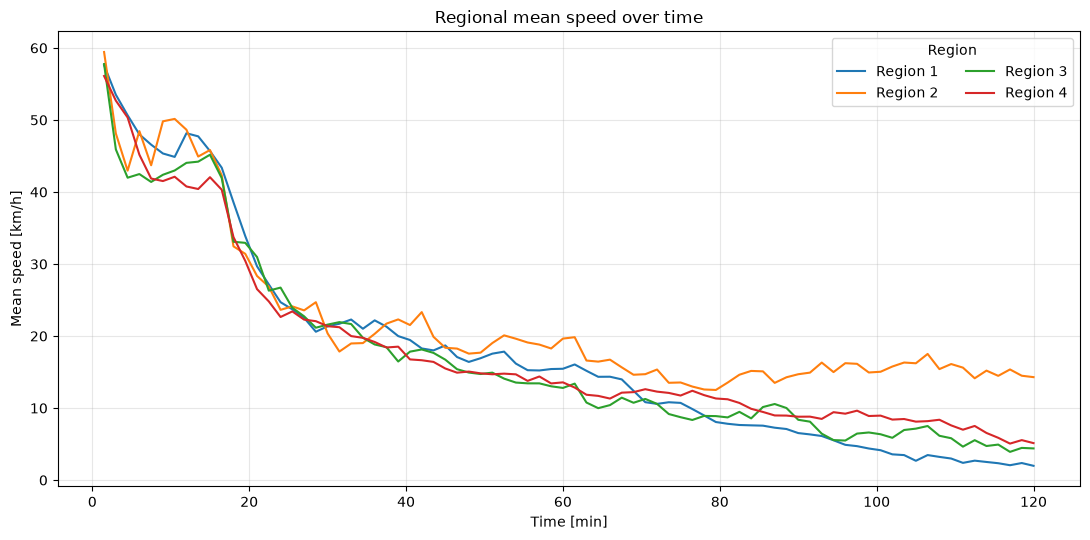

In [ ]:


DETECTOR_LENGTH_M = 2.0
AVERAGE_VEHICLE_LENGTH_M = 5.0


def estimate_region_traffic(data_dir=data_dir, csv_path=None):
    links = pd.read_csv(
        data_dir / "links.csv",
        header=None,
        names=["link_id", "length_m", "lanes", "start_node", "end_node", "region"],
    )

    def read_measurements(filename):
        raw = pd.read_csv(data_dir / filename, header=None)
        link_ids = raw.iloc[0, 1:].astype(int).to_numpy()
        if len(np.unique(link_ids)) != len(link_ids):
            raise ValueError(f"Duplicate link IDs found in {filename}.")
        times_s = raw.iloc[1:, 0].astype(float).to_numpy()
        values = raw.iloc[1:, 1:].astype(float).to_numpy()
        return times_s, link_ids, values

    occupancy_times, occupancy_ids, occupancy = read_measurements("occupancy.csv")
    flow_times, flow_ids, flow = read_measurements("flow.csv")

    if not np.array_equal(occupancy_times, flow_times):
        raise ValueError("flow.csv and occupancy.csv have different time steps.")
    intervals_s = np.diff(flow_times)
    if len(intervals_s) == 0 or np.any(intervals_s <= 0):
        raise ValueError("Measurement times must contain positive intervals.")
    if not np.allclose(intervals_s, intervals_s[0]):
        raise ValueError("flow.csv must use a constant measurement interval.")

    link_ids = links["link_id"].astype(int).to_numpy()

    def align_columns(values, measurement_ids, filename):
        id_to_column = {link_id: index for index, link_id in enumerate(measurement_ids)}
        missing = [link_id for link_id in link_ids if link_id not in id_to_column]
        if missing:
            raise ValueError(f"Links missing from {filename}: {missing[:10]}")
        return values[:, [id_to_column[link_id] for link_id in link_ids]]

    occupancy = align_columns(occupancy, occupancy_ids, "occupancy.csv")
    flow = align_columns(flow, flow_ids, "flow.csv")
    flow_rate = flow * (3600.0 / intervals_s[0])

    lanes = links["lanes"].to_numpy(dtype=float)
    density = (
        (occupancy / 100.0)
        * lanes[None, :]
        / (AVERAGE_VEHICLE_LENGTH_M + DETECTOR_LENGTH_M)
        * 1000.0
    )
    print(density)
    dataframedensity = pd.DataFrame(density)
    dataframedensity.to_csv(data_dir / "density.csv", index=False, header=False)
    regions = links["region"].to_numpy()
    link_lengths = links["length_m"].to_numpy(dtype=float)
    time_min = occupancy_times / 60.0

    if csv_path is not None:
        n_times, n_links = density.shape
        link_density_table = pd.DataFrame(
            {
                "time_s": np.repeat(occupancy_times, n_links),
                "time_min": np.repeat(time_min, n_links),
                "link_id": np.tile(link_ids, n_times),
                "region": np.tile(regions, n_times),
                "link_length_m": np.tile(link_lengths, n_times),
                "lanes": np.tile(lanes, n_times),
                "occupancy_percent": occupancy.reshape(-1),
                "average_vehicle_length_m": AVERAGE_VEHICLE_LENGTH_M,
                "detector_length_m": DETECTOR_LENGTH_M,
                "density_veh_per_km": density.reshape(-1),
            }
        )
        link_density_table.to_csv(
            csv_path,
            index=False,
        )

    records = []

    for region in np.sort(pd.unique(regions)):
        in_region = regions == region
        lengths = link_lengths[in_region]
        density_length = density[:, in_region] * lengths[None, :]
        denominator = density_length.sum(axis=1)
        mean_density = denominator / lengths.sum()
        mean_speed = np.divide(
            (flow_rate[:, in_region] * lengths[None, :]).sum(axis=1),
            denominator,
            out=np.full(len(time_min), np.nan),
            where=denominator > 0,
        )

        records.extend(
            {
                "time_min": time,
                "region": region,
                "mean_density_veh_per_km": average_density,
                "mean_speed_km_per_h": average_speed,
            }
            for time, average_density, average_speed in zip(
                time_min, mean_density, mean_speed
            )
        )

    return pd.DataFrame(records)


def plot_region_traffic(results):
    regions = np.sort(results["region"].unique())
    n_regions = len(regions)
    n_cols = int(np.ceil(np.sqrt(n_regions)))
    n_rows = int(np.ceil(n_regions / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows),
        squeeze=False,
    )
    axes = axes.ravel()
    time_min = results["time_min"]
    scatter = None

    for ax, region in zip(axes, regions):
        region_data = results[results["region"] == region]
        scatter = ax.scatter(
            region_data["mean_density_veh_per_km"],
            region_data["mean_speed_km_per_h"],
            c=region_data["time_min"],
            cmap="viridis",
            vmin=time_min.min(),
            vmax=time_min.max(),
            s=22,
            alpha=0.8,
        )
        ax.set_title(f"Region {region}")
        ax.set_xlabel("Mean density [veh/km]")
        ax.set_ylabel("Mean speed [km/h]")
        ax.grid(True, alpha=0.25)

    for ax in axes[n_regions:]:
        ax.set_visible(False)

    fig.suptitle("Regional mean speed vs. mean density")
    fig.subplots_adjust(top=0.88, right=0.87, wspace=0.3, hspace=0.35)
    colorbar_ax = fig.add_axes([0.90, 0.2, 0.025, 0.65])
    fig.colorbar(scatter, cax=colorbar_ax, label="Time [min]")

    fig, ax = plt.subplots(figsize=(11, 5.5))
    for region in regions:
        region_data = results[results["region"] == region]
        ax.plot(
            region_data["time_min"],
            region_data["mean_speed_km_per_h"],
            label=f"Region {region}",
        )

    ax.set_title("Regional mean speed over time")
    ax.set_xlabel("Time [min]")
    ax.set_ylabel("Mean speed [km/h]")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Region", ncol=2)
    fig.tight_layout()
    plt.show()


if __name__ == "__main__":
    csv_path = data_dir / "link_density_estimates.csv"
    regional_results = estimate_region_traffic(csv_path=csv_path)
    valid_speeds = regional_results["mean_speed_km_per_h"].dropna()
    print(f"Link density table saved to: {csv_path}")
    print(
        "Regional mean speed range: "
        f"{valid_speeds.min():.2f} to {valid_speeds.max():.2f} km/h"
    )
    plot_region_traffic(regional_results)

STEP 4

C:\Users\grego\AppData\Local\Temp\ipykernel_126536\2633142894.py:122: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


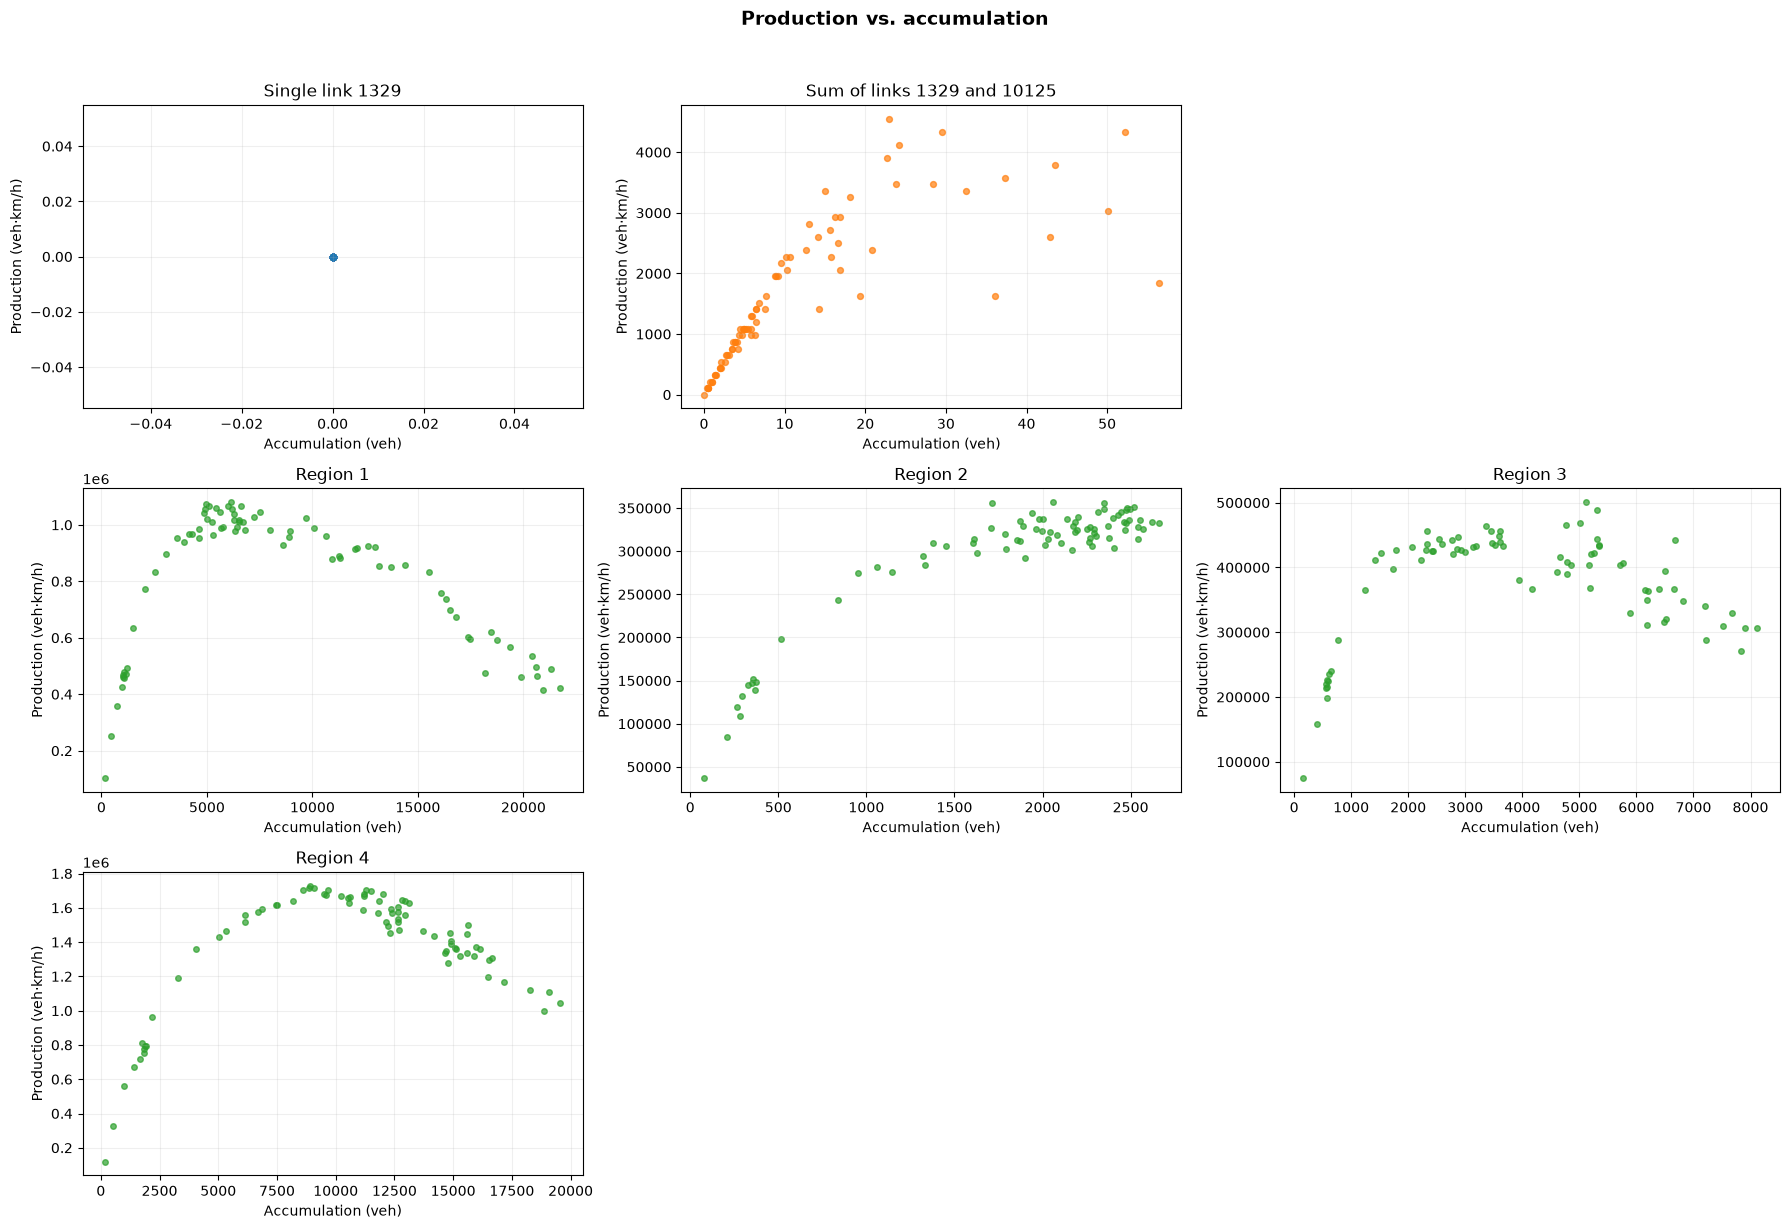

In [ ]:
def load_traffic_data():
    
   

    links = pd.read_csv(
        data_dir / "links.csv",
        header=None,
        names=["link_id", "length_km", "lanes", "start_node", "end_node", "region"],
    )

    flow_raw = pd.read_csv(data_dir / "flow.csv", header=None)
    occupancy_raw = pd.read_csv(data_dir / "occupancy.csv", header=None)

    flow_ids = flow_raw.iloc[0, 1:].astype(int).to_numpy()
    occupancy_ids = occupancy_raw.iloc[0, 1:].astype(int).to_numpy()

    flow_times = flow_raw.iloc[1:, 0].to_numpy(dtype=float)
    occupancy_times = occupancy_raw.iloc[1:, 0].to_numpy(dtype=float)

    flow_matrix = flow_raw.iloc[1:, 1:].to_numpy(dtype=float)
    occupancy_matrix = occupancy_raw.iloc[1:, 1:].to_numpy(dtype=float)

    links_order = links["link_id"].to_numpy(dtype=int)

    flow_lookup = {link_id: idx for idx, link_id in enumerate(flow_ids)}
    occupancy_lookup = {link_id: idx for idx, link_id in enumerate(occupancy_ids)}

    flow_aligned = np.zeros((len(flow_times), len(links_order)))
    occupancy_aligned = np.zeros((len(occupancy_times), len(links_order)))

    for j, link_id in enumerate(links_order):
        if link_id not in flow_lookup:
            raise ValueError(f"Link {link_id} is missing from flow.csv")
        if link_id not in occupancy_lookup:
            raise ValueError(f"Link {link_id} is missing from occupancy.csv")

        flow_aligned[:, j] = flow_matrix[:, flow_lookup[link_id]]
        occupancy_aligned[:, j] = occupancy_matrix[:, occupancy_lookup[link_id]]

    return links, flow_times, occupancy_times, flow_aligned, occupancy_aligned


def compute_link_metrics(links, flow_matrix, occupancy_matrix):
    """Compute accumulation and production per link across time."""
    lengths = links["length_km"].to_numpy(dtype=float)

    if np.nanmax(occupancy_matrix) <= 100:
        density = occupancy_matrix / 100.0
    else:
        density = occupancy_matrix

    accumulation = density * lengths[np.newaxis, :]
    production = flow_matrix * lengths[np.newaxis, :]

    return accumulation, production


def plot_production_accumulation():

    links, _, _, flow_matrix, occupancy_matrix = load_traffic_data()
    accumulation, production = compute_link_metrics(links, flow_matrix, occupancy_matrix)

    rng = np.random.default_rng(42)
    all_link_ids = links["link_id"].to_numpy(dtype=int)

    random_link_id = int(rng.choice(all_link_ids))
    random_link_index = int(np.where(all_link_ids == random_link_id)[0][0])

    eligible_links = np.delete(all_link_ids, np.where(all_link_ids == random_link_id)[0][0])
    second_link_id = int(rng.choice(eligible_links))
    second_link_index = int(np.where(all_link_ids == second_link_id)[0][0])

    fig = plt.figure(figsize=(18, 12), constrained_layout=True)

    regions = sorted(links["region"].unique())
    n_regions = len(regions)
    ncols = min(3, n_regions)
    nrows = int(np.ceil(n_regions / ncols)) + 1
    gs = fig.add_gridspec(nrows, 3)

    ax = fig.add_subplot(gs[0, 0])
    ax.scatter(
        accumulation[:, random_link_index],
        production[:, random_link_index],
        s=18,
        alpha=0.7,
        color="tab:blue",
    )
    ax.set_xlabel("Accumulation (veh)")
    ax.set_ylabel("Production (veh·km/h)")
    ax.set_title(f"Single link {random_link_id}")
    ax.grid(True, alpha=0.2)

    ax = fig.add_subplot(gs[0, 1])
    acc_sum = accumulation[:, random_link_index] + accumulation[:, second_link_index]
    prod_sum = production[:, random_link_index] + production[:, second_link_index]
    ax.scatter(acc_sum, prod_sum, s=18, alpha=0.7, color="tab:orange")
    ax.set_xlabel("Accumulation (veh)")
    ax.set_ylabel("Production (veh·km/h)")
    ax.set_title(f"Sum of links {random_link_id} and {second_link_id}")
    ax.grid(True, alpha=0.2)

    for i, region in enumerate(regions):
        row = i // ncols
        col = i % ncols
        ax_region = fig.add_subplot(gs[1 + row, col])

        region_link_ids = links.loc[links["region"] == region, "link_id"].to_numpy(dtype=int)
        region_indices = [int(np.where(all_link_ids == link_id)[0][0]) for link_id in region_link_ids]

        region_accumulation = accumulation[:, region_indices].sum(axis=1)
        region_production = production[:, region_indices].sum(axis=1)

        ax_region.scatter(region_accumulation, region_production, s=16, alpha=0.7, color="tab:green")
        ax_region.set_title(f"Region {region}")
        ax_region.set_xlabel("Accumulation (veh)")
        ax_region.set_ylabel("Production (veh·km/h)")
        ax_region.grid(True, alpha=0.2)

    fig.suptitle("Production vs. accumulation", y=1.02, fontsize=14, fontweight="bold")
    fig.tight_layout()
    plt.savefig(data_dir / "production_vs_accumulation.png", dpi=200)
    plt.show()


if __name__ == "__main__":
    plot_production_accumulation()


STEP 5

In [61]:
#Code of Step 5

STEP 6

[ 28.68173532 180.6397478  188.36004048 ...  28.550965    57.97044614
 225.45538664]
(1570,)


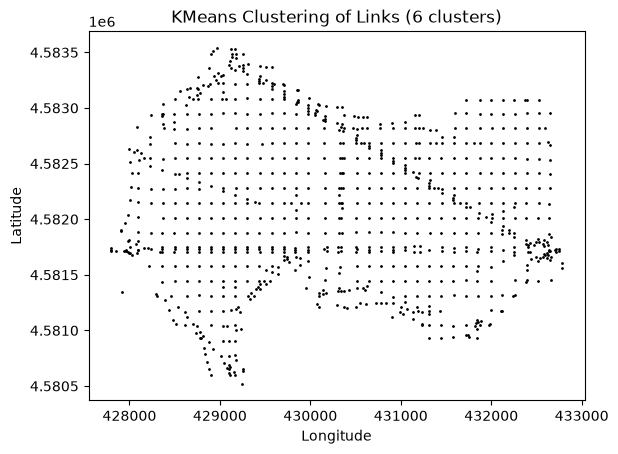

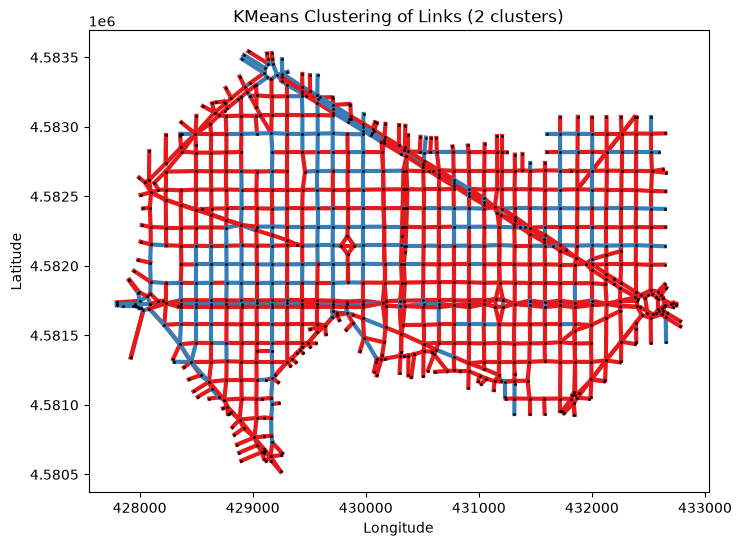

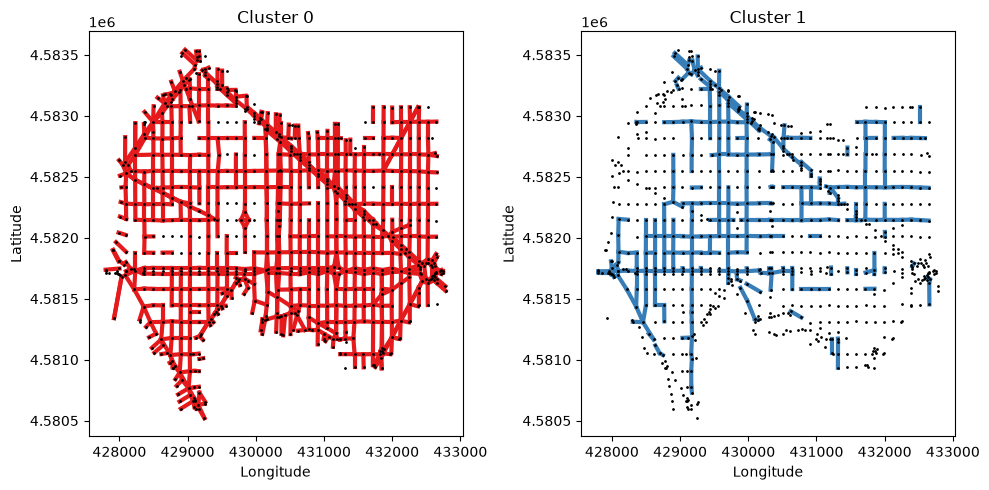

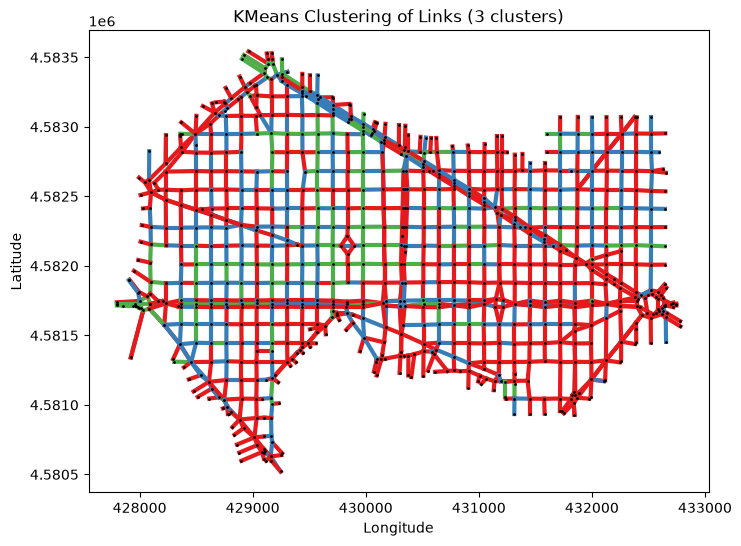

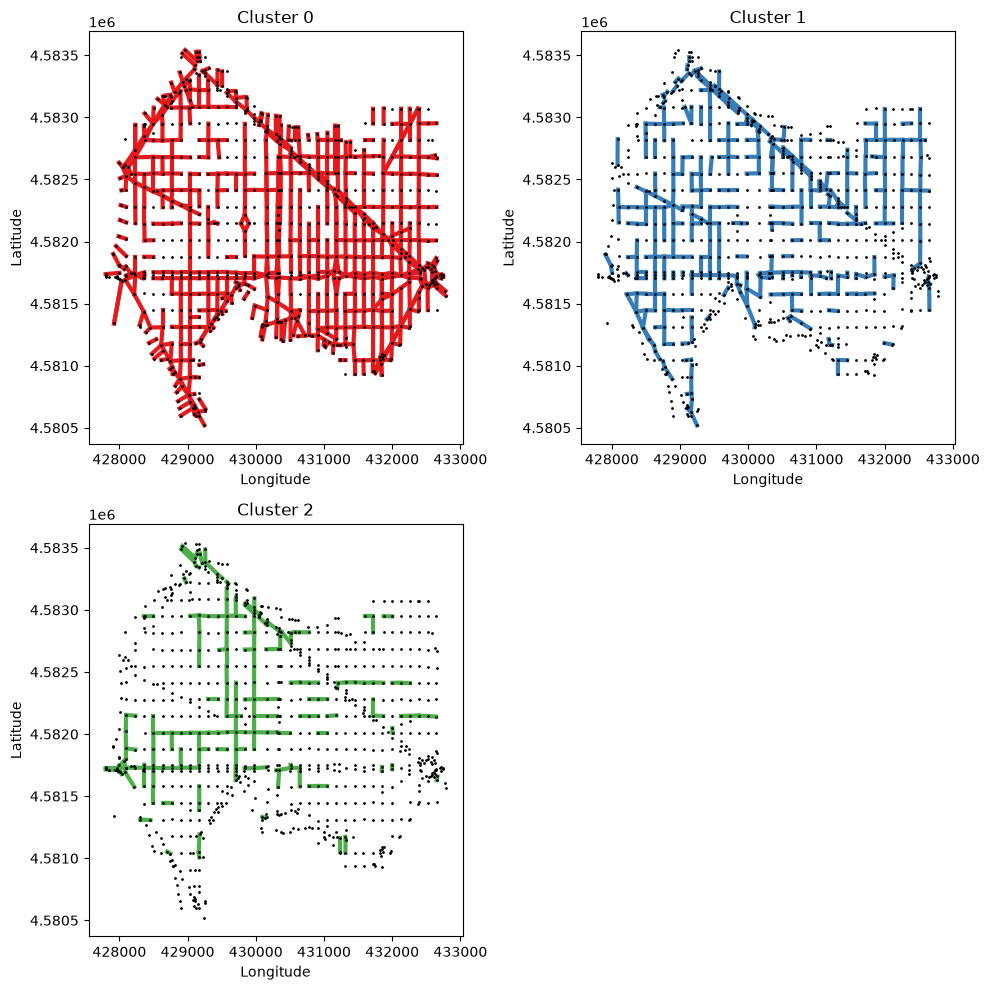

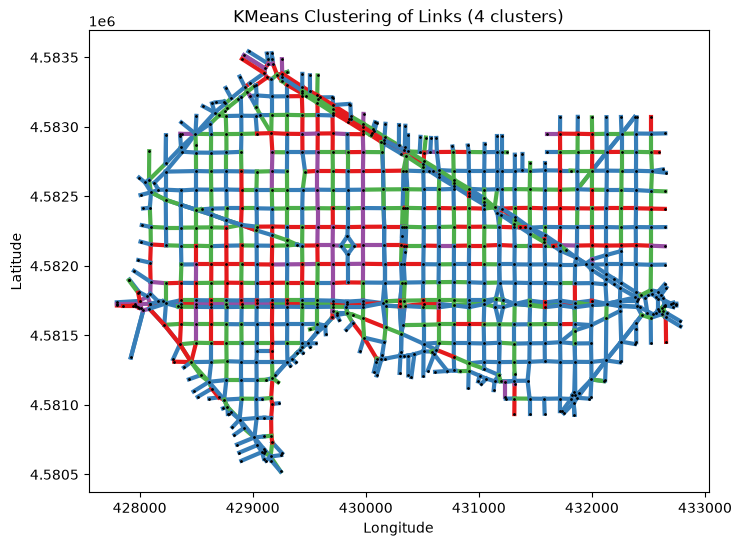

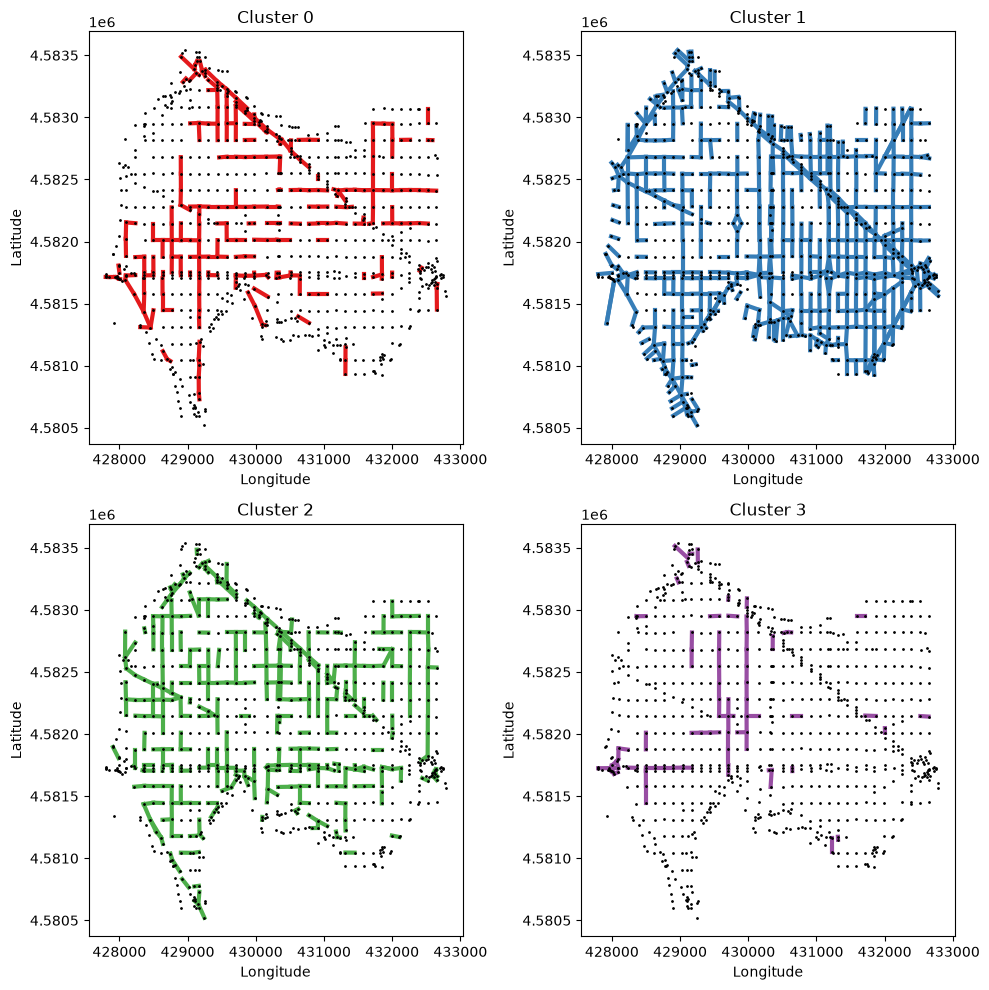

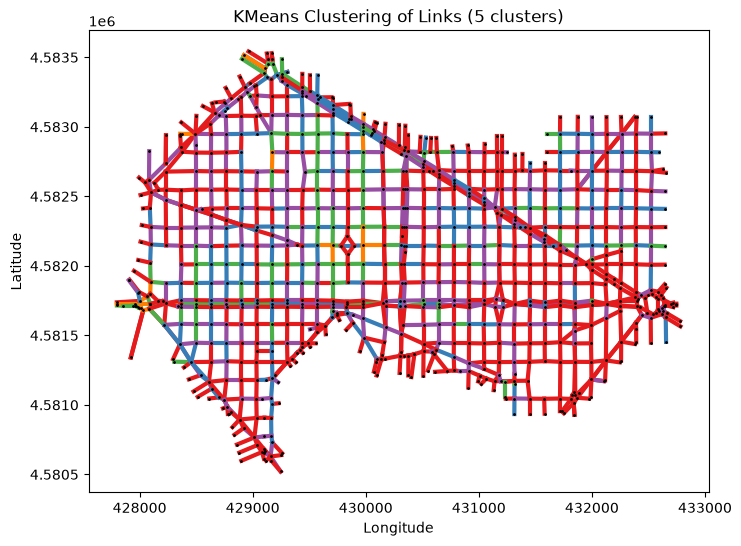

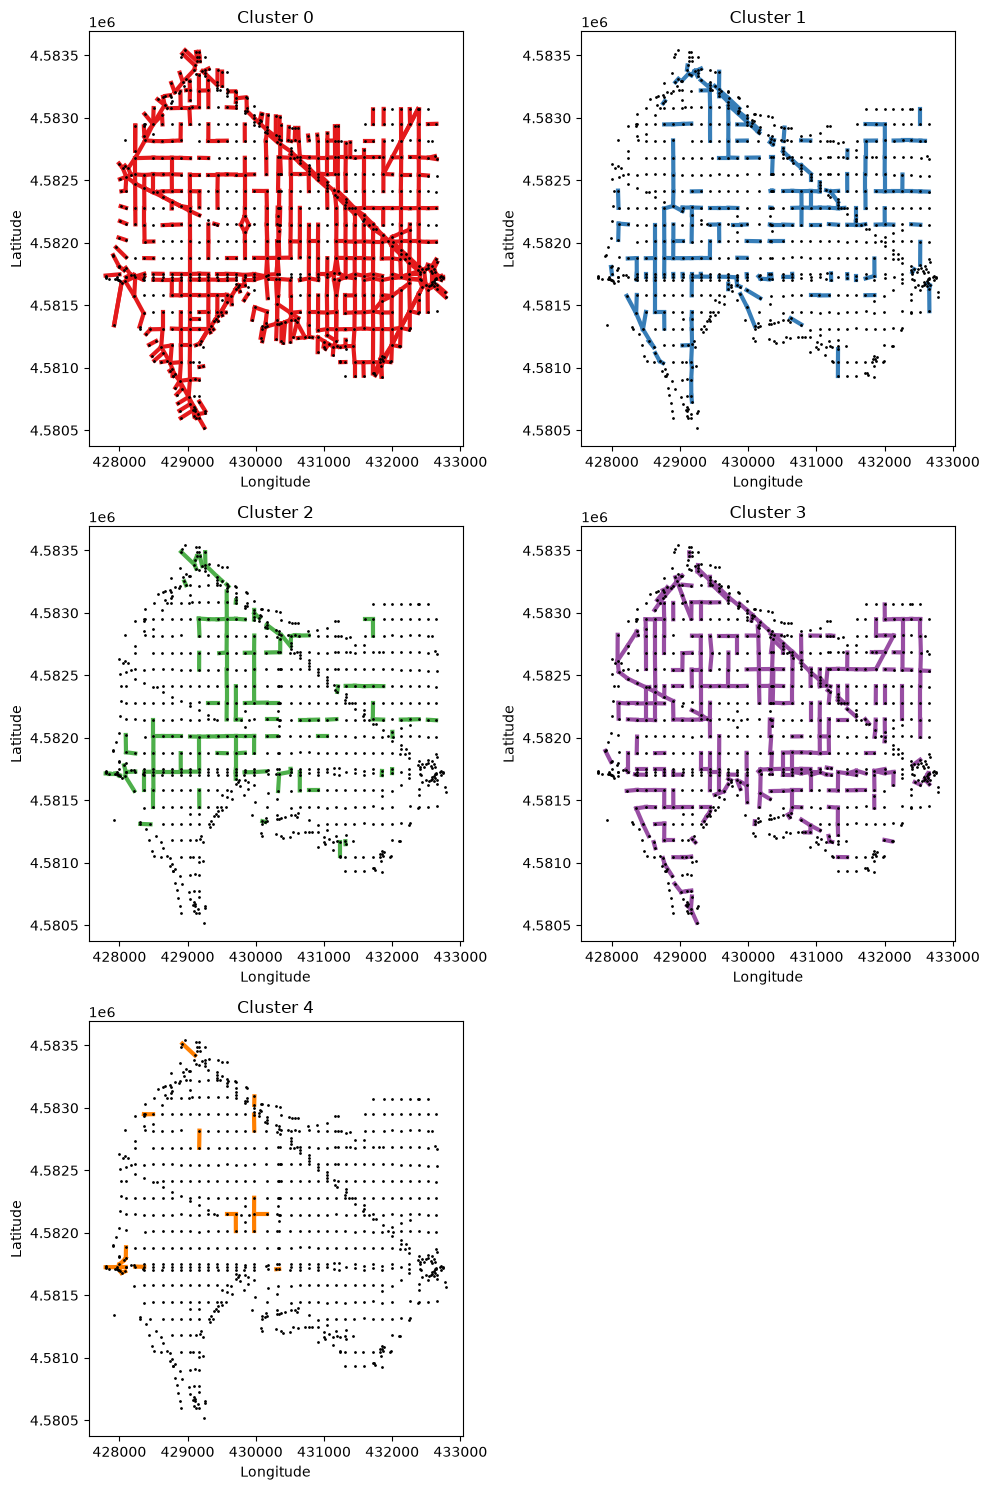

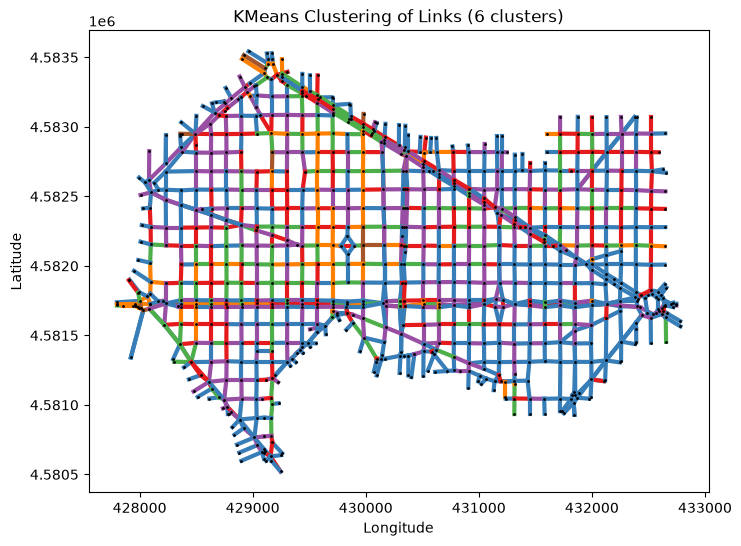

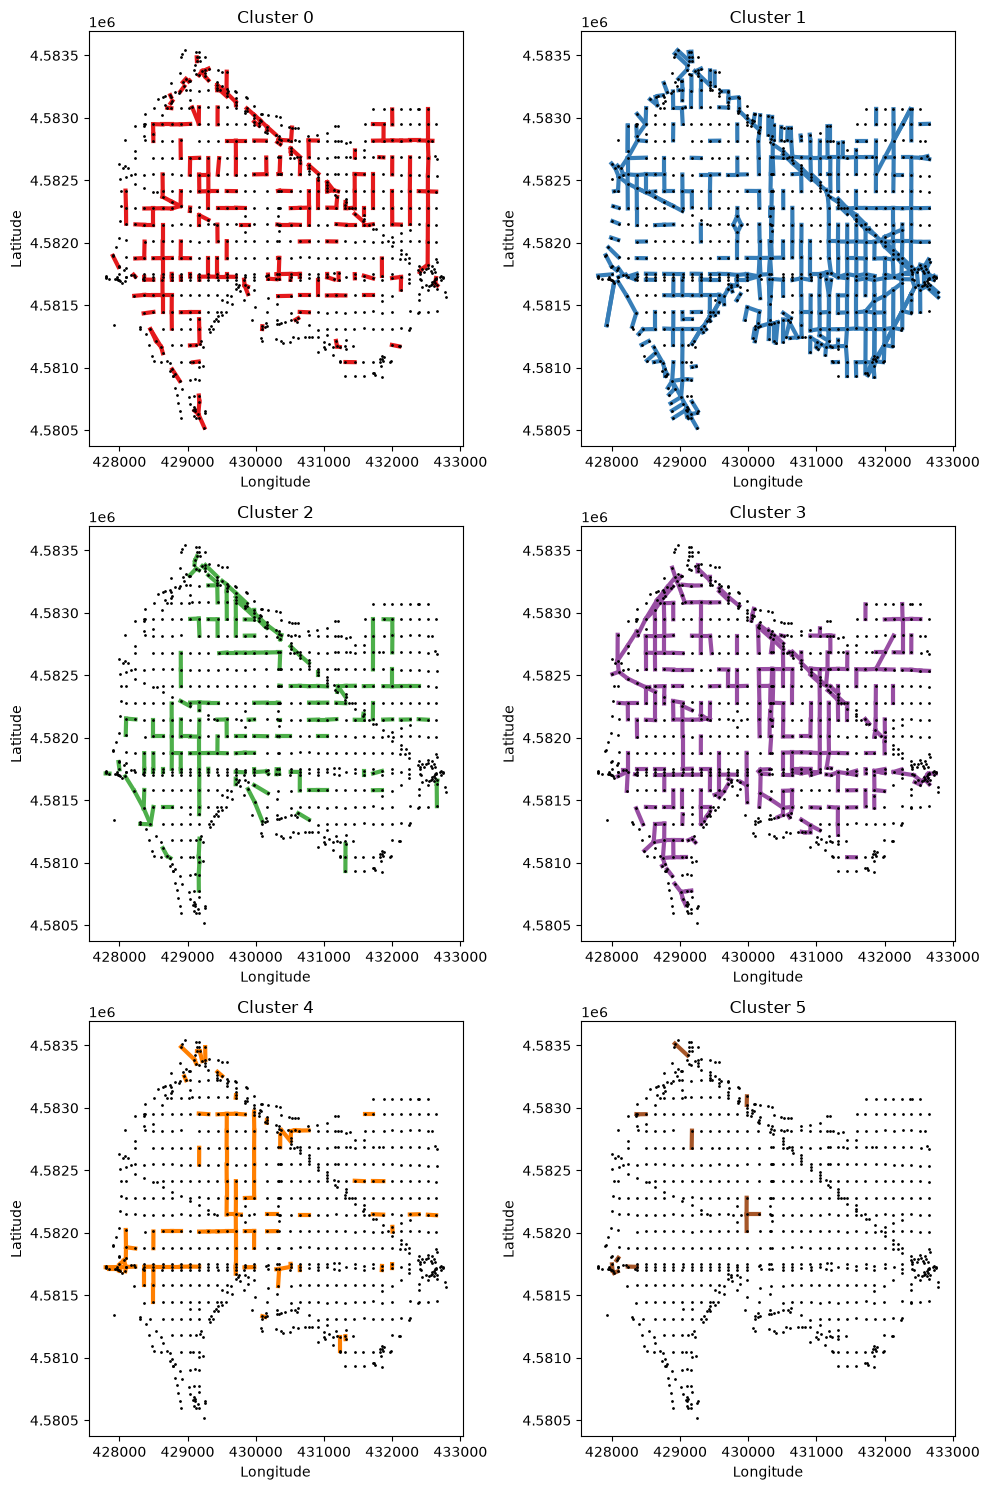

In [ ]:


flow = pd.read_csv(
        data_dir / "flow.csv",
        header=None
    ).to_numpy()
occupancy = pd.read_csv(
        data_dir / "occupancy.csv",
        header=None
    ).to_numpy()
links = pd.read_csv(
        data_dir / "links.csv",
        header=None
    ).to_numpy()
nodes = pd.read_csv(
        data_dir / "nodes.csv",
        header=None
    ).to_numpy()
density = pd.read_csv(
        data_dir / "density.csv",
        header=None
    ).to_numpy()

np.mean(occupancy[1:,1:], axis=0)
np.std(occupancy[1:,1:], axis=0)
meandensity=np.mean(density[:,:], axis=0)

print(meandensity)
standardized_mean_density = np.zeros_like(meandensity)
print(np.shape(meandensity))
standardized_mean_density[:] = (meandensity - np.mean(meandensity[:], axis=0)) / np.std(meandensity, axis=0)

matrice = standardized_mean_density[:].astype(float)
matrice = np.nan_to_num(matrice, nan=0.0, posinf=0.0, neginf=0.0)
links2 = pd.read_csv(
        data_dir / "links.csv",
        header=None
    )
nodes2 = pd.read_csv(
        data_dir / "nodes.csv",
        header=None
    )
df_left = pd.merge(links2, nodes2, left_on=3, right_on=0, how='left')
df_final = pd.merge(df_left, nodes2, left_on=4, right_on=0, how='left')
df_final['meandensity'] = meandensity
numberk=[2,3,4,5,6]
for k in numberk:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=1).fit_predict(matrice.reshape(-1, 1))
    df_final[f'cluster_{k}'] = kmeans



plt.scatter(nodes2[1], nodes2[2], s=1, zorder=2, color="black")
plt.title(f"KMeans Clustering of Links ({k} clusters)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()




cluster_colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#a65628"]

for k in numberk:
    labels = df_final[f"cluster_{k}"]

    plt.figure(figsize=(8, 6))
    for _, sub in df_final.iterrows():
        xs = [sub.iloc[7], sub.iloc[10]]
        ys = [sub.iloc[8], sub.iloc[11]]
        cluster = int(sub[f"cluster_{k}"])
        plt.plot(
            xs,
            ys,
            color=cluster_colors[cluster % len(cluster_colors)],
            linewidth=3,
            alpha=1,
            zorder=1,
        )

    plt.scatter(nodes2[1], nodes2[2], s=1, zorder=2, color="black")
    plt.title(f"KMeans Clustering of Links ({k} clusters)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()





    rows = int(np.ceil(k / 2))
    fig, axes = plt.subplots(rows, 2, figsize=(10, 5 * rows), squeeze=False)
    for i in range(k):
        ax = axes[i // 2, i % 2]
        ax.set_title(f"Cluster {i}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        for _, sub in df_final.iterrows():
            if sub[f"cluster_{k}"] == i:
                xs = [sub.iloc[7], sub.iloc[10]]
                ys = [sub.iloc[8], sub.iloc[11]]
                ax.plot(
                    xs,
                    ys,
                    color=cluster_colors[i % len(cluster_colors)],
                    linewidth=3,
                    alpha=1,
                    zorder=1,
                )
        ax.scatter(nodes2[1], nodes2[2], s=1, zorder=2, color="black")

    for i in range(k, rows * 2):
        axes[i // 2, i % 2].set_visible(False)
    plt.tight_layout()
    plt.show()


STEP 7

   0_x         1_x  2_x      3      4  5    0_y     1_y      2_y      0  \
0  512  109.223913    3  21109  19069  4  21109  429978  4582998  19069   
1  513  129.668254    3  19067  21109  4  19067  429848  4583054  21109   
2  514  133.572478    2  19065  21042  4  19065  429844  4583038  21042   
3  516   47.649608    2     11  19201  3     11  432591  4582817  19201   
4  593   96.553539    3  18703     84  4  18703  432649  4581714     84   

        1        2  meandensity  cluster_2  cluster_3  cluster_4  cluster_5  \
0  429868  4583056    28.681735          0          0          1          0   
1  429978  4582998   180.639748          1          2          0          1   
2  429976  4582971   188.360040          1          2          0          1   
3  432524  4582818   140.229132          1          1          0          1   
4  432747  4581715    44.803212          0          0          1          0   

   cluster_6  
0          1  
1          2  
2          2  
3          0  

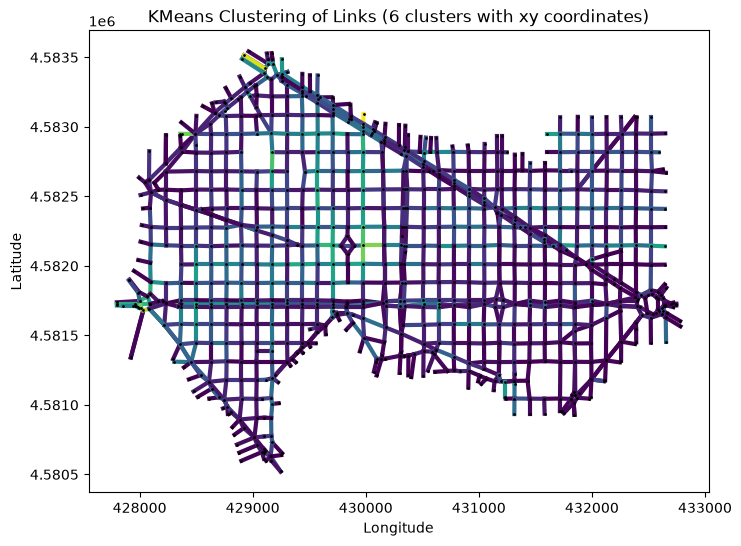

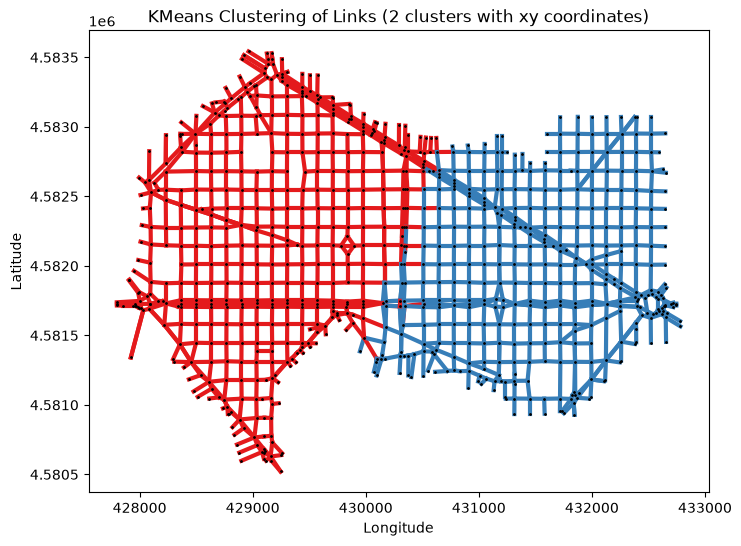

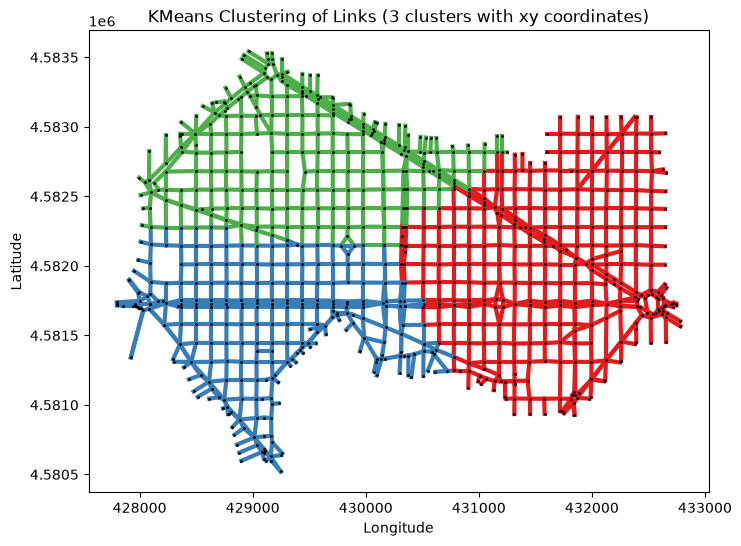

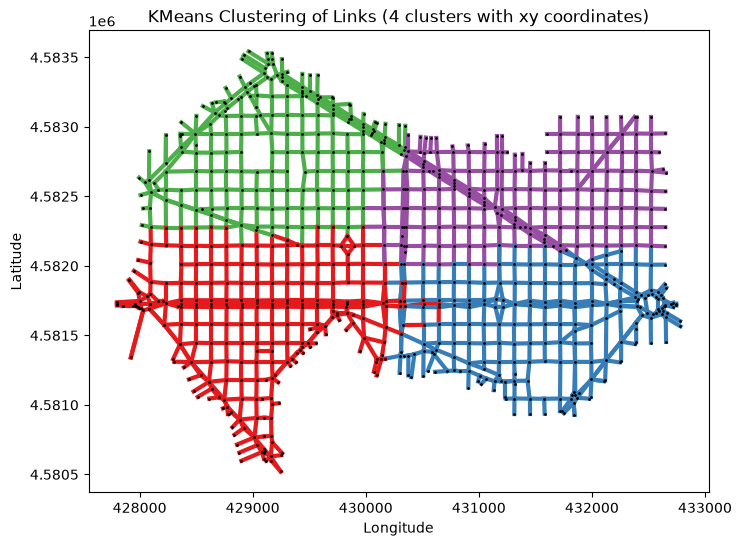

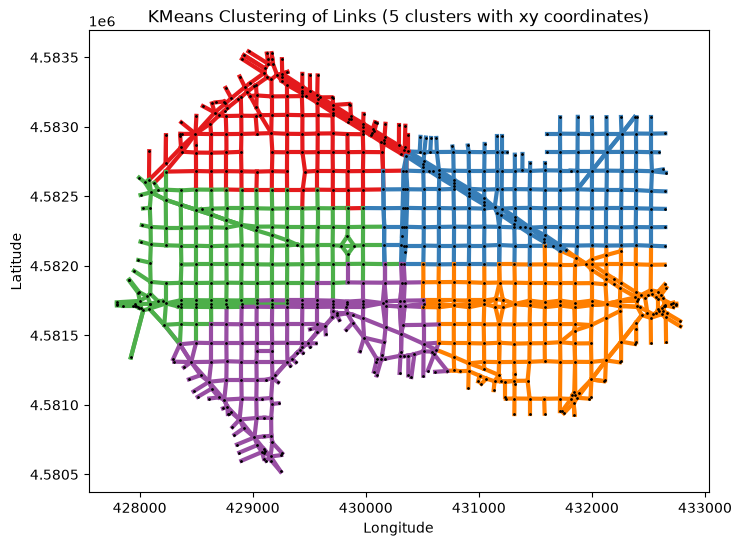

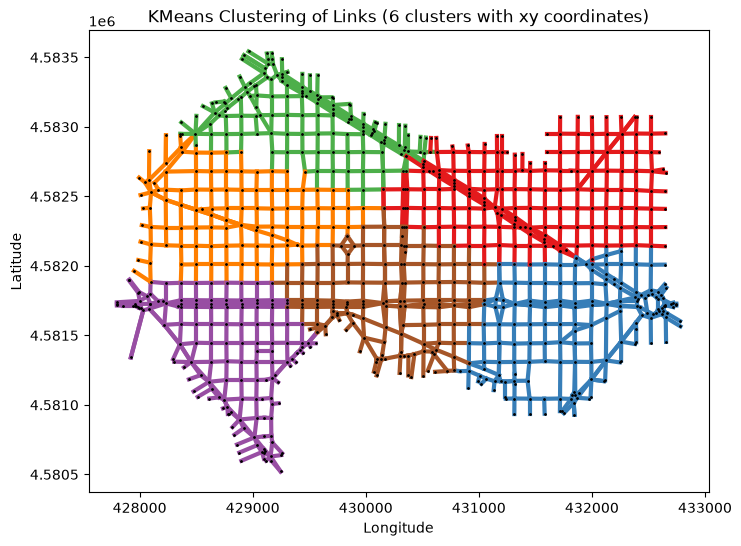

In [63]:
kpoint=[1.82,2.63,1.76,2.91,2.97]
print(df_final.head())
df_final['xmean']=(df_final.iloc[:, 10] + df_final.iloc[:, 7])/2
df_final['ymean']=(df_final.iloc[:, 11] + df_final.iloc[:, 8])/2
df_final['xmeannormalized']=(df_final['xmean']-np.mean(df_final['xmean']))/np.std(df_final['xmean'])
df_final['ymeannormalized']=(df_final['ymean']-np.mean(df_final['ymean']))/np.std(df_final['ymean'])
df_final["standardized_meandensity"] = (df_final["meandensity"] - np.mean(df_final["meandensity"])) / np.std(df_final["meandensity"])

numberk=[2,3,4,5,6]
for k in numberk:
    matrice = df_final[['xmeannormalized', 'ymeannormalized', 'standardized_meandensity']].to_numpy()
    print("avant",matrice)
    matrice[:, 0]=kpoint[k-2]*matrice[:, 0]
    matrice[:, 1]=kpoint[k-2]*matrice[:, 1]
    print("apres",matrice)
    print(np.shape(matrice))
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=1).fit_predict(matrice)
    print(f"Cluster labels for k={k}: {kmeans}")
    print(np.shape(kmeans))
    df_final[f'clusterxy_{k}'] = kmeans


segments = []
for i in range(len(df_final)):
    x1 = df_final.iloc[i, 5]
    y1 = df_final.iloc[i, 6]
    x2 = df_final.iloc[i, 8]
    y2 = df_final.iloc[i, 9]
    segments.append([(x1, y1), (x2, y2)])


plt.figure(figsize=(8, 6))
for i, sub in df_final.iterrows():
    xs = [sub.iloc[7], sub.iloc[10]]
    ys = [sub.iloc[8], sub.iloc[11]]
    cluster = int(sub[f"clusterxy_{k}"])
    plt.plot(
        xs,
        ys,
        color=plt.cm.viridis(
            plt.Normalize(np.nanmin(meandensity), np.nanmax(meandensity))(meandensity[i])
        ),
        linewidth=3,
        alpha=1,
        zorder=1,
    )

plt.scatter(nodes2[1], nodes2[2], s=1, zorder=2, color="black")
plt.title(f"KMeans Clustering of Links ({k} clusters with xy coordinates)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()




cluster_colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#a65628"]

for k in numberk:
    labels = df_final[f"clusterxy_{k}"]

    plt.figure(figsize=(8, 6))
    for _, sub in df_final.iterrows():
        xs = [sub.iloc[7], sub.iloc[10]]
        ys = [sub.iloc[8], sub.iloc[11]]
        cluster = int(sub[f"clusterxy_{k}"])
        plt.plot(
            xs,
            ys,
            color=cluster_colors[cluster % len(cluster_colors)],
            linewidth=3,
            alpha=1,
            zorder=1,
        )

    plt.scatter(nodes2[1], nodes2[2], s=1, zorder=2, color="black")
    plt.title(f"KMeans Clustering of Links ({k} clusters with xy coordinates)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()